# Condition-Aware Dual-Stream Transformer
## Remaining Useful Life Prediction on the NASA C-MAPSS Dataset
**Author**: Piyush
**Dataset**: NASA C-MAPSS (FD001 - FD004)
**Framework**: PyTorch

### Abstract
This notebook presents a state-of-the-art methodology for Remaining Useful Life (RUL) prediction in turbofan engines using the NASA C-MAPSS dataset. By framing the problem through multi-task learning, we jointly optimize for both binary classification (degraded-state classification using a 50-cycle threshold) and continuous regression (estimating exact RUL). The proposed architecture, a Condition-Aware Dual-Stream Transformer, introduces a Variable Selection Network (VSN) for feature gating, a multi-scale Temporal Convolutional Network (TCN) for short-term pattern extraction, and a bidirectional GRU conditioned on operating regimes for long-term wear tracking. Furthermore, our approach normalizes sensors on a per-regime basis to prevent transition noise across varying altitude and Mach settings, while leveraging MC Dropout to obtain a stochastic predictive uncertainty signal through repeated inference.


## Table of Contents
1. [Introduction](#1.-Introduction)
2. [Environment Setup](#2.-Environment-Setup)
3. [Experiment Configuration](#3.-Experiment-Configuration)
4. [Dataset Description](#4.-Dataset-Description)
5. [Data Utilities](#5.-Data-Utilities)
6. [Data Preprocessing](#6.-Data-Preprocessing)
7. [Proposed Architecture](#7.-Proposed-Architecture)
8. [Loss Functions](#8.-Loss-Functions)
9. [Model Components](#9.-Model-Components)
10. [Condition-Aware Dual Stream Transformer](#10.-Condition-Aware-Dual-Stream-Transformer)
11. [Training Pipeline](#11.-Training-Pipeline)
12. [Evaluation](#12.-Evaluation)
13. [Results](#13.-Results)
14. [Conclusion](#14.-Conclusion)


## 1. Introduction

Predictive Maintenance (PdM) is a critical component of modern industrial operations, aiming to optimize maintenance schedules and minimize unexpected downtime. Central to PdM is the estimation of the **Remaining Useful Life (RUL)**, defined as the amount of time or cycles an asset can continue to operate before it requires repair or replacement.

The **NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)** dataset is a widely adopted benchmark for RUL prediction. It simulates the degradation of turbofan engines under varying operational conditions (e.g., altitude, Mach number, and throttle setting) and records multi-variate sensor responses leading up to catastrophic failure.

### Why Multi-Task Learning?
Approaching RUL prediction as a pure regression task often yields poor accuracy at the boundaries (e.g., early-life vs. degraded state). By reformulating the problem into a multi-task framework—simultaneously learning binary classification (healthy vs. degraded) and regression—the model can construct better internal representations of the critical failure threshold, resulting in significantly enhanced precision when it matters most.

### Why Uncertainty Estimation?
In safety-critical systems such as aerospace engines, point predictions alone may not fully characterize predictive reliability. We therefore integrate Monte Carlo (MC) Dropout during inference, performing repeated stochastic forward passes to obtain a predictive uncertainty signal. Classification entropy from the averaged stochastic predictions is used to quantify relative predictive uncertainty across operating conditions.


## 2. Environment Setup


In [1]:
import os
import math
import pandas as pd
import numpy as np

try:
    get_ipython().__class__.__name__
except NameError:
    import matplotlib
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Random Seed Configuration
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Hardware Acceleration Setup
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    try:
        import subprocess
        gpu_name = subprocess.check_output(
            ['sysctl', '-n', 'machdep.cpu.brand_string']).decode().strip() + " (Unified GPU)"
    except Exception:
        gpu_name = "Apple Silicon Unified GPU (MPS)"
else:
    device = torch.device('cpu')
    gpu_name = "None (CPU)"

print(f"Device : {device.type}")
print(f"PyTorch: {torch.__version__}")
print(f"GPU    : {gpu_name}")


Device : cuda
PyTorch: 2.11.0+cu128
GPU    : Tesla T4


## 3. Experiment Configuration


In [3]:
# Global Hyperparameters
SEQ_LENGTH = 40
BATCH_SIZE = 64
LR = 5e-4
EPOCHS = 150
PATIENCE = 45
RUL_CAP = 125
NUM_CLUSTERS = 6

index_names   = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = [f's_{i}' for i in range(1, 22)]
col_names     = index_names + setting_names + sensor_names


## 4. Dataset Description

The NASA C-MAPSS dataset consists of 4 distinct sub-datasets (FD001 to FD004), varying by the number of operational regimes and fault modes.

| Dataset | Regimes (Conditions) | Fault Modes | Train Engines | Test Engines |
|---------|----------------------|-------------|---------------|--------------|
| **FD001** | 1 (Sea Level) | 1 (HPC Degradation) | 100 | 100 |
| **FD002** | 6 (Various Altitudes/Mach) | 1 (HPC Degradation) | 260 | 259 |
| **FD003** | 1 (Sea Level) | 2 (HPC + Fan Degradation) | 100 | 100 |
| **FD004** | 6 (Various Altitudes/Mach) | 2 (HPC + Fan Degradation) | 249 | 248 |

### Features
Each temporal sequence contains 21 sensors (`s_1` to `s_21`) and 3 operational settings (`setting_1` to `setting_3`). Sensors track physical thermodynamic variables such as temperature, pressure, and fan speed.


## 5. Data Utilities


In [4]:
def get_file_path(filename):
    if os.path.exists(filename):
        return filename
    elif os.path.exists(os.path.join('Dataset', filename)):
        return os.path.join('Dataset', filename)
    raise FileNotFoundError(f"Cannot find {filename} in current directory or Dataset/ folder.")

def add_rul(df):
    rul = pd.DataFrame(df.groupby('unit_nr')['time_cycles'].max()).reset_index()
    rul.columns = ['unit_nr', 'max']
    df = df.merge(rul, on=['unit_nr'], how='left')
    df['RUL'] = df['max'] - df['time_cycles']
    df['RUL'] = df['RUL'].clip(upper=125)
    df.drop('max', axis=1, inplace=True)
    return df

def get_class(rul):
    return 1 if rul <= 50 else 0  # 1=Degraded, 0=Healthy

def cluster_operating_conditions(df, n_clusters=6, dataset_name=None):
    """
    Cluster operating conditions using KMeans on setting_1, setting_2, setting_3.
    For FD001/FD003 (single condition), KMeans is bypassed and regime=0 is assigned unconditionally.
    """
    if dataset_name in ['FD001', 'FD003']:
        df['regime'] = 0
        return df, 1
    settings = df[['setting_1', 'setting_2', 'setting_3']].values
    if np.std(settings) < 0.01:
        df['regime'] = 0
        return df, 1
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['regime'] = km.fit_predict(settings)
    return df, km

class ConditionAwareScaler:
    """
    Condition-Aware Scaler:
    - Sensors (s_1..s_21): Normalized strictly WITHIN each operating regime (MinMaxScaler per regime)
      to eliminate altitude and Mach transition jumps.
    - Settings (setting_1..setting_3): Normalized GLOBALLY so the neural network retains absolute
      altitude and throttle context without near-zero variance division issues inside KMeans clusters.
    """
    def __init__(self):
        self.scalers = {}
        self.global_scaler = MinMaxScaler()
        self.setting_cols = []
        self.sensor_cols = []

    def fit_transform(self, df, features, regime_col='regime'):
        result = df.copy()
        self.setting_cols = [c for c in features if c.startswith('setting_')]
        self.sensor_cols  = [c for c in features if c.startswith('s_')]

        if self.setting_cols:
            result[self.setting_cols] = self.global_scaler.fit_transform(df[self.setting_cols])

        for regime in df[regime_col].unique():
            mask = df[regime_col] == regime
            if self.sensor_cols:
                scaler = MinMaxScaler()
                result.loc[mask, self.sensor_cols] = scaler.fit_transform(df.loc[mask, self.sensor_cols])
                self.scalers[regime] = scaler
        return result[features].values

    def transform(self, df, features, regime_col='regime'):
        result = df.copy()
        if self.setting_cols:
            result[self.setting_cols] = self.global_scaler.transform(df[self.setting_cols])

        for regime in df[regime_col].unique():
            mask = df[regime_col] == regime
            if self.sensor_cols:
                if regime in self.scalers:
                    result.loc[mask, self.sensor_cols] = self.scalers[regime].transform(
                        df.loc[mask, self.sensor_cols])
                else:
                    closest = min(self.scalers.keys(), key=lambda r: abs(r - regime))
                    result.loc[mask, self.sensor_cols] = self.scalers[closest].transform(
                        df.loc[mask, self.sensor_cols])
        return result[features].values

def generate_sequences(df, seq_length, feature_cols, regime_col='regime'):
    """Generate ALL overlapping windows with 2D regime sequences [N, T]."""
    seqs, labels, ruls, regimes = [], [], [], []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        data_matrix = unit_data[feature_cols].values
        label_array = unit_data['label'].values
        rul_array   = unit_data['RUL'].values
        reg_array   = unit_data[regime_col].values
        for i in range(len(unit_data) - seq_length + 1):
            seqs.append(data_matrix[i:i+seq_length])
            labels.append(label_array[i+seq_length-1])
            ruls.append(rul_array[i+seq_length-1])
            regimes.append(reg_array[i:i+seq_length])
    return np.array(seqs), np.array(labels), np.array(ruls), np.array(regimes)

def generate_sequences_weighted(df, seq_length, feature_cols, regime_col='regime'):
    """
    Generate sequences with HP-optimized importance weights for HP-optimized importance-weighted oversampling.
    Balanced Multi-Stage Weighting:
    - Degraded-state horizon (RUL <= 30) gets weight 2.5 (NASA score focus)
    - Boundary zone (30 < RUL <= 65) gets weight 2.0 (Classification precision focus)
    - Healthy / mid-life (RUL > 65) gets weight 1.2 (Ensuring strong regression accuracy on healthy engines)
    """
    seqs, labels, ruls, weights, regimes = [], [], [], [], []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        data_matrix = unit_data[feature_cols].values
        label_array = unit_data['label'].values
        rul_array   = unit_data['RUL'].values
        reg_array   = unit_data[regime_col].values
        for i in range(len(unit_data) - seq_length + 1):
            seqs.append(data_matrix[i:i+seq_length])
            labels.append(label_array[i+seq_length-1])
            rul_val = rul_array[i+seq_length-1]
            ruls.append(rul_val)
            regimes.append(reg_array[i:i+seq_length])
            if rul_val <= 30:
                w = 2.5
            elif rul_val <= 65:
                w = 2.0
            else:
                w = 1.2
            weights.append(w)
    return (np.array(seqs), np.array(labels),
            np.array(ruls), np.array(weights), np.array(regimes))

def nasa_score(y_true, y_pred):
    """NASA asymmetric scoring function for RUL prediction."""
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return float(np.sum(scores))


## 6. Data Preprocessing

To ensure the neural network receives clean, regime-invariant signals, the data preprocessing pipeline applies a strict sequence of operations:

1. **Load Data**: The raw text files are parsed into Pandas DataFrames.
2. **Generate RUL**: True Remaining Useful Life is calculated backwards from the final failure cycle, capped at a maximum of `RUL_CAP=125` to promote early-life regression stability.
3. **Assign Class Labels**: Engines with `RUL <= 50` are marked as degraded (`1`), and healthy otherwise (`0`).
4. **Cluster Operating Regimes**: For multi-regime datasets (FD002/FD004), KMeans clustering groups the 3 operational settings into 6 distinct regimes.
5. **Normalize (Condition-Aware)**: Sensors are scaled using `MinMaxScaler` on a strictly *per-regime* basis. This eliminates massive cross-regime baseline shifts caused by altitude and Mach changes, mapping all sensors to a unified `[0, 1]` scale. Operational settings are scaled globally.
6. **EMA Denoising**: After scaling, an Exponential Moving Average (EMA) with a span of 5 is applied to denoise high-frequency sensor noise. Because it is applied *after* per-regime scaling, it does not blend raw values across regime transitions.
7. **Sequence Generation**: Sliding windows of size `SEQ_LENGTH=40` are extracted for sequence modeling.


## 7. Proposed Architecture

Our **Condition-Aware Dual-Stream Transformer** is a hybrid dual-stream deep learning architecture optimized for multi-variate time-series degradation tracking.

* **Variable Selection Network (VSN)**: Employs independent feature gating via a Sigmoid activation ($2\sigma(\cdot)$) to identify and amplify informative sensors while suppressing noisy channels, preventing input signal attenuation.
* **Stream A (Multi-Scale TCN)**: Captures local, high-frequency signal spikes using parallel dilated convolutions (dilations 1, 2, 4, 8).
* **Stream B (Conditioned BiGRU)**: Tracks long-term, cumulative engine wear. It is explicitly conditioned on 32D operational regime embeddings to contextualize the degradation trajectory.
* **Cross-Stream Fusion**: A learned sigmoid gate adaptively merges the local (TCN) and global (BiGRU) representations.
* **Transformer Encoder**: Applies 4 layers of self-attention enhanced with Sinusoidal Positional Embeddings for absolute temporal position.
* **Adaptive Attention Pooling**: Aggregates the sequence temporally by concatenating attention-pooled states, the mean trajectory, and the element-wise temporal maximum representation.
* **Squeeze-and-Excitation (SE)**: Applies channel-wise attention to the pooled representation.
* **Dual Heads**: Decoupled MLP heads output the final Binary Classification (degraded probability) and Regression (RUL value) predictions.


## 8. Loss Functions

The model optimizes a joint loss function $L_{total} = L_{cls} + \alpha L_{reg}$.

1. **Focal Loss ($L_{cls}$)**: Down-weights easily classified healthy engines, forcing the network to focus on the hard boundary cases (RUL near 50).
2. **NASA Asymmetric Loss ($L_{reg}$)**: An exponentially-scaled, asymmetric loss function that penalizes late predictions (over-estimating RUL, which leads to catastrophic failure) far more heavily than early predictions (under-estimating RUL). The loss incorporates a quadratic fine-tuning core via Smooth L1.


In [5]:
class FocalLoss(nn.Module):
    """Focal Loss — down-weights easy samples, focuses on hard boundary cases."""
    def __init__(self, alpha=0.1, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(inputs, targets, reduction='none')
        pt         = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

class NASAAsymmetricLoss(nn.Module):
    """
    HP-Optimized Regression loss inspired by the NASA scoring function.
    Penalizes late predictions (pred > true, i.e. over-estimating RUL) more
    heavily than early predictions, mirroring the real-world cost.

    Smooth L1 beta reduced to 5.0 for quadratic fine-tuning
    on sub-5 cycle errors. Error clamping set to [-30, 30] and nasa_weight set
    to 0.10 to eliminate gradient explosions during regime switches.
    """
    def __init__(self, a1=13.0, a2=10.0, smoothl1_beta=5.0, nasa_weight=0.10):
        super().__init__()
        self.a1 = a1
        self.a2 = a2
        self.smoothl1 = nn.SmoothL1Loss(beta=smoothl1_beta)
        self.nasa_weight = nasa_weight

    def forward(self, pred, target):
        d = pred - target
        d_clamped = torch.clamp(d, -30, 30)
        nasa_loss = torch.where(
            d_clamped < 0,
            torch.exp(-d_clamped / self.a1) - 1,
            torch.exp( d_clamped / self.a2) - 1
        ).mean()
        smooth_loss = self.smoothl1(pred, target)
        return smooth_loss + self.nasa_weight * nasa_loss


## 9. Model Components


### Variable Selection Network
Independent gating of the input sensors to isolate key deterioration signals.


In [6]:
class VariableSelectionNetwork(nn.Module):
    """
    Learned independent variable importance gating.
    Replaced Softmax gating with independent Sigmoid activation (2 * sigmoid).
    Gates are now computed per-timestep by applying GRN across the sequence dimension.
    """
    def __init__(self, num_features, d_model):
        super().__init__()
        self.grn = nn.Sequential(
            nn.Linear(num_features, d_model),
            nn.GELU(),
            nn.Linear(d_model, num_features),
        )
        self.proj = nn.Conv1d(num_features, d_model, kernel_size=1, bias=False)

    def forward(self, x):
        # x: (B, num_features, T)
        x_trans = x.transpose(1, 2)  # (B, T, num_features)
        weights = 2.0 * torch.sigmoid(self.grn(x_trans)) # (B, T, num_features)
        weights = weights.transpose(1, 2) # (B, num_features, T)
        x_gated = x * weights
        return self.proj(x_gated)  # (B, d_model, T)


### Multi-Scale TCN
Stream A: Extracts local temporal patterns using parallel dilated convolutions.


In [7]:
class MultiScaleTCN(nn.Module):
    """Stream A: Multi-scale TCN with parallel dilated branches (d=1,2,4,8).
    Note: Uses symmetric padding (non-causal), suitable for windowed batch prediction."""
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        branch_dim = d_model // 4
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(d_model, branch_dim, kernel_size=3, padding=d, dilation=d, bias=False),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            for d in [1, 2, 4, 8]
        ])
        self.proj = nn.Conv1d(branch_dim * 4, d_model, kernel_size=1, bias=False)
        self.norm = nn.LayerNorm(d_model)
        self.skip = nn.Conv1d(d_model, d_model, kernel_size=1, bias=False)

    def forward(self, x):
        # x: (B, d_model, T)
        branches = [branch(x) for branch in self.branches]
        min_len = min(b.size(2) for b in branches)
        branches = [b[:, :, -min_len:] for b in branches]
        out = self.proj(torch.cat(branches, dim=1))
        skip = self.skip(x[:, :, -min_len:])
        result = out + skip
        result = self.norm(result.permute(0, 2, 1)).permute(0, 2, 1)
        return result


### Conditioned BiGRU
Stream B: Tracking cumulative temporal wear, conditioned on regime embeddings.


In [8]:
class ConditionedBiGRU(nn.Module):
    """Stream B: Bidirectional GRU conditioned on 32D regime embeddings. Tracks cumulative wear."""
    def __init__(self, d_model, d_cond=32, dropout=0.1):
        super().__init__()
        self.cond_proj = nn.Linear(d_cond, d_model) if d_cond else None
        self.gru = nn.GRU(d_model, d_model // 2, bidirectional=True, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_time, cond=None):
        # x_time: (B, T, d_model), cond: (B, T, d_cond)
        h = x_time
        if self.cond_proj is not None and cond is not None:
            h = h + self.cond_proj(cond)
        out, _ = self.gru(h)
        return self.norm(self.dropout(out) + x_time)


### Cross-Stream Fusion
Learned gating mechanism to merge representations from Stream A and Stream B.


In [9]:
class CrossStreamGatedFusion(nn.Module):
    """Gated fusion merging Stream A (local noise/spikes) and Stream B (cumulative wear)."""
    def __init__(self, d_model):
        super().__init__()
        self.gate_fc = nn.Linear(d_model * 2, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, stream_a, stream_b):
        # stream_a, stream_b: (B, T, d_model)
        combined = torch.cat([stream_a, stream_b], dim=-1)
        z = torch.sigmoid(self.gate_fc(combined))
        fused = z * stream_a + (1 - z) * stream_b
        return self.norm(fused)


### Sinusoidal Positional Encoding
Fixed sinusoidal positional encoding is added to the Transformer input to provide information about the absolute temporal position of each timestep in the sequence.


In [10]:
class SinusoidalPositionalEncoding(nn.Module):
    """Positional encoding with sinusoidal patterns for absolute temporal position information."""
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


### Gated Residual Network
Non-linear feature transformation layer with timestep-wise operating condition support.


In [11]:
class GatedResidualNetwork(nn.Module):
    """Gated Residual Network with timestep-wise 32D operating condition conditioning."""
    def __init__(self, d_model, d_cond=None, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_model)
        self.fc2 = nn.Linear(d_model, d_model)
        self.gate = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.cond_proj = nn.Linear(d_cond, d_model) if d_cond else None

    def forward(self, x, cond=None):
        # x: (B, T, d_model), cond: (B, T, d_cond)
        residual = x
        h = self.fc1(x)
        if self.cond_proj is not None and cond is not None:
            h = h + self.cond_proj(cond)
        h = F.gelu(h)
        h = self.dropout(self.fc2(h))
        gate = torch.sigmoid(self.gate(h))
        return self.norm(gate * h + (1 - gate) * residual)


### Adaptive Attention Pooling
Temporal sequence aggregation combining attention, mean, and max pooling.


In [12]:
class AdaptiveAttentionPooling(nn.Module):
    """Learned attention pooling over temporal sequence + mean + max pooling."""
    def __init__(self, d_model, d_cond=None):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=4, batch_first=True, dropout=0.1)
        self.cond_proj = nn.Linear(d_cond, d_model) if d_cond else None

    def forward(self, x, cond_last=None):
        # x: (B, T, d_model), cond_last: (B, d_cond)
        B = x.size(0)
        q = self.query.expand(B, -1, -1)
        if self.cond_proj is not None and cond_last is not None:
            q = q + self.cond_proj(cond_last).unsqueeze(1)
        attn_out, _ = self.attn(q, x, x)
        attn_pool = attn_out.squeeze(1)
        mean_pool = x.mean(dim=1)
        max_pool  = x.max(dim=1).values
        return torch.cat([attn_pool, mean_pool, max_pool], dim=1)  # (B, 3*d_model)


### Squeeze-and-Excitation
Channel-wise recalibration of the pooled representation.


In [13]:
class SqueezeExcitation(nn.Module):
    """SE channel attention for pooled representations."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.se = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.GELU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(x)


## 10. Condition-Aware Dual-Stream Transformer
The final unified architecture bringing together all previously defined components.


In [14]:
class ConditionAwareDualStreamTransformer(nn.Module):
    """
    Condition-Aware Dual-Stream Transformer.

    Dual-stream architecture:
    VSN (Sigmoid Gating) -> Stream A (Multi-Scale TCN) + Stream B (Conditioned BiGRU) ->
    Cross-Stream Gated Fusion -> GRN (32D cond) -> Transformer Encoder (Sinusoidal Positional Encoding) ->
    Adaptive Attention Pooling -> SE -> Dual Heads.
    """
    def __init__(self, num_features, num_classes=2, d_model=128,
                 n_heads=8, n_layers=4, n_regimes=7, dropout=0.15):
        super().__init__()
        d_cond = 32
        self.regime_embedding = nn.Embedding(n_regimes, d_cond)
        self.vsn = VariableSelectionNetwork(num_features, d_model)

        # Stream A & Stream B
        self.tcn = MultiScaleTCN(d_model, dropout=dropout)
        self.bigru = ConditionedBiGRU(d_model, d_cond=d_cond, dropout=dropout)
        self.fusion = CrossStreamGatedFusion(d_model)

        self.grn = GatedResidualNetwork(d_model, d_cond=d_cond, dropout=dropout)
        self.pos_enc = SinusoidalPositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 2,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.pool = AdaptiveAttentionPooling(d_model, d_cond=d_cond)
        pool_dim = d_model * 3
        self.se = SqueezeExcitation(pool_dim, reduction=4)

        self.fc_class = nn.Sequential(
            nn.Linear(pool_dim, 128),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, num_classes)
        )

        self.fc_reg = nn.Sequential(
            nn.Linear(pool_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, regime_ids=None):
        B, _, T = x.size()
        if regime_ids is None:
            regime_ids = torch.zeros((B, T), dtype=torch.long, device=x.device)
        elif regime_ids.dim() == 1:
            regime_ids = regime_ids.unsqueeze(1).expand(-1, T)

        cond = self.regime_embedding(regime_ids)  # (B, T, d_cond)

        x_gated = self.vsn(x)                              # (B, d_model, T)
        stream_a = self.tcn(x_gated).permute(0, 2, 1)      # (B, T, d_model)
        stream_b = self.bigru(x_gated.permute(0, 2, 1), cond) # (B, T, d_model)

        x_fused = self.fusion(stream_a, stream_b)          # (B, T, d_model)
        x_fused = self.grn(x_fused, cond)                  # (B, T, d_model)
        x_fused = self.pos_enc(x_fused)
        x_out = self.transformer(x_fused)                  # (B, T, d_model)

        pooled = self.pool(x_out, cond_last=cond[:, -1, :]) # (B, 3*d_model)
        pooled = self.se(pooled)

        out_class = self.fc_class(pooled)
        out_reg   = self.fc_reg(pooled)
        return out_class, out_reg


## 11. Evaluation
Monte Carlo (MC) Dropout Inference for Predictive Uncertainty Estimation.


In [15]:
def mc_dropout_inference(model, data_loader, num_passes=25, has_regime=True):
    model.train()
    all_probs, all_regs, all_targets = [], [], []

    with torch.no_grad():
        for batch in data_loader:
            inputs, labels_cls = batch[0].to(device), batch[1]
            if has_regime and len(batch) >= 4:
                regime_ids = batch[3].to(device)
            else:
                regime_ids = None



            pass_probs, pass_regs = [], []
            for _ in range(num_passes):
                out_cls, out_reg = model(inputs, regime_ids=regime_ids)
                pass_probs.append(torch.softmax(out_cls, dim=1).unsqueeze(0))
                pass_regs.append(out_reg.unsqueeze(0))

            mean_probs = torch.cat(pass_probs, dim=0).mean(dim=0)
            mean_regs  = torch.cat(pass_regs,  dim=0).mean(dim=0)

            all_probs.append(mean_probs.cpu())
            all_regs.append(mean_regs.cpu())
            all_targets.append(labels_cls.cpu())

    all_probs   = torch.cat(all_probs,   dim=0).numpy()
    all_regs    = torch.cat(all_regs,    dim=0).squeeze().numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    preds_cls = np.argmax(all_probs, axis=1)
    entropy   = -np.sum(all_probs * np.log(all_probs + 1e-9), axis=1)
    return preds_cls, all_regs, all_targets, entropy


## 12. Training Pipeline
The complete data pipeline, training loop, and evaluation execution for a given dataset.


In [16]:
def train_and_evaluate_dataset(dataset_name, epochs=150, sequence_length=40, seed=42):
    import random
    def set_seed(seed):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        elif torch.backends.mps.is_available():
            torch.mps.manual_seed(seed)

    set_seed(seed)

    print(f"\n{'='*54}")
    print(f"      PROCESSING DATASET: {dataset_name}")
    print(f"{'='*54}")

    # ── Load & preprocess train ────────────────────────────────────────
    # ---------------------------------------------------
    # Load Training Data
    # ---------------------------------------------------
    train_data = pd.read_csv(get_file_path(f'train_{dataset_name}.txt'),
                             sep=r'\s+', header=None, names=col_names)
    train_data = add_rul(train_data)
    train_data['label'] = train_data['RUL'].apply(get_class)

    features = [c for c in train_data.columns
                if c not in ['unit_nr', 'time_cycles', 'RUL', 'label', 'regime']
                and train_data[c].std() > 1e-5]

    # ── Operating Condition Clustering (Explicit Regime Handling) ─────
    # ---------------------------------------------------
    # Operating Condition Clustering
    # ---------------------------------------------------
    train_data, km_model = cluster_operating_conditions(
        train_data, n_clusters=6, dataset_name=dataset_name)
    n_regimes = len(train_data['regime'].unique())
    print(f"  Detected {n_regimes} operating regime(s) for {dataset_name}")

    # ── Unit-level 80/20 train/validation split ────────────────────────────────────
    unique_units  = train_data['unit_nr'].unique()
    engine_labels = [get_class(train_data[train_data['unit_nr']==u]['RUL'].max())
                     for u in unique_units]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for tr_idx, va_idx in sss.split(unique_units, engine_labels):
        train_units, val_units = unique_units[tr_idx], unique_units[va_idx]

    train_df = train_data[train_data['unit_nr'].isin(train_units)].copy()
    val_df   = train_data[train_data['unit_nr'].isin(val_units)].copy()

    # ── HP-Optimized Normalization (Settings Global, Sensors Per-Regime) ──
    # NOTE: We normalize with ConditionAwareScaler FIRST
    # so that all regimes live on a unified [0, 1] scale. This prevents EMA denoising
    # from blending raw physical sensor values across altitude/Mach regime switches!
    # ---------------------------------------------------
    # Normalization
    # ---------------------------------------------------
    scaler = ConditionAwareScaler()
    train_df[features] = scaler.fit_transform(train_df, features)
    val_df[features]   = scaler.transform(val_df, features)

    # ── Selective EMA Denoising (Applied AFTER Normalization) ─────────
    sensor_cols = [c for c in features if c.startswith('s_')]
    for df_ in [train_df, val_df]:
        df_[sensor_cols] = df_.groupby('unit_nr')[sensor_cols].transform(
            lambda x: x.ewm(span=5, adjust=False).mean())

    # ── Sequence Generation with HP-Optimized Curriculum Weights ─────
    # ---------------------------------------------------
    # Sequence Generation
    # ---------------------------------------------------
    X_train, y_train_cls, y_train_reg, w_train, r_train = generate_sequences_weighted(
        train_df, sequence_length, features)
    X_val, y_val_cls, y_val_reg, _, r_val = generate_sequences_weighted(
        val_df, sequence_length, features)

    # ── Load & preprocess test ────────────────────────────────────────
    test_data = pd.read_csv(get_file_path(f'test_{dataset_name}.txt'),
                            sep=r'\s+', header=None, names=col_names)
    if isinstance(km_model, int):  # single regime
        test_data['regime'] = 0
    else:
        test_data['regime'] = km_model.predict(
            test_data[['setting_1', 'setting_2', 'setting_3']].values)

    test_data_full = test_data[['unit_nr', 'time_cycles', 'regime'] + features].copy()
    test_data_full[features] = scaler.transform(test_data_full, features)
    test_data_full[sensor_cols] = test_data_full.groupby('unit_nr')[sensor_cols].transform(
        lambda x: x.ewm(span=5, adjust=False).mean())

    X_test, r_test = [], []
    for unit in test_data_full['unit_nr'].unique():
        ud = test_data_full[test_data_full['unit_nr'] == unit]
        if len(ud) >= sequence_length:
            seq = ud[features].values[-sequence_length:]
            regime = ud['regime'].values[-sequence_length:]
        else:
            seq = np.zeros((sequence_length, len(features)))
            seq[-len(ud):] = ud[features].values
            regime = np.zeros(sequence_length, dtype=int)
            if len(ud) > 0:
                regime[-len(ud):] = ud['regime'].values
        X_test.append(seq)
        r_test.append(regime)
    X_test = np.array(X_test)
    r_test = np.array(r_test)

    true_rul = pd.read_csv(get_file_path(f'RUL_{dataset_name}.txt'),
                           sep=r'\s+', header=None, names=['RUL'])
    true_rul['RUL'] = true_rul['RUL'].clip(upper=125)
    y_test_reg = true_rul['RUL'].values
    y_test_cls = true_rul['RUL'].apply(get_class).values

    # ── Tensor conversion ─────────────────────────────────────────────
    # ---------------------------------------------------
    # Tensor Conversion
    # ---------------------------------------------------
    def to_tensor(X, y_cls, y_reg):

        return (torch.tensor(X, dtype=torch.float32).permute(0, 2, 1),
                torch.tensor(y_cls, dtype=torch.long),
                torch.tensor(y_reg, dtype=torch.float32).unsqueeze(1))


    X_train_t, y_train_cls_t, y_train_reg_t = to_tensor(X_train, y_train_cls, y_train_reg)
    X_val_t,   y_val_cls_t,   y_val_reg_t = to_tensor(X_val,   y_val_cls,   y_val_reg)
    X_test_t,  y_test_cls_t,  y_test_reg_t = to_tensor(X_test,  y_test_cls,  y_test_reg)

    r_train_t = torch.tensor(np.array(r_train, dtype=np.int64), dtype=torch.long)
    r_val_t   = torch.tensor(np.array(r_val, dtype=np.int64),   dtype=torch.long)
    r_test_t  = torch.tensor(np.array(r_test, dtype=np.int64),  dtype=torch.long)

    # ── Weighted Sampler for HP-optimized importance-weighted oversampling ──────────────────────
    # ---------------------------------------------------
    # Data Loaders
    # ---------------------------------------------------
    gen = torch.Generator().manual_seed(seed)
    sampler = WeightedRandomSampler(
        weights=w_train, num_samples=len(w_train), replacement=True, generator=gen)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_cls_t, y_train_reg_t, r_train_t),
        batch_size=64, sampler=sampler, drop_last=True)
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_cls_t, y_val_reg_t, r_val_t),
        batch_size=64, shuffle=False)
    test_loader = DataLoader(
        TensorDataset(X_test_t,  y_test_cls_t,  y_test_reg_t, r_test_t),
        batch_size=64, shuffle=False)

    # ── Model, Loss, Optimizer  ──────────────────────
    # ---------------------------------------------------
    # Model Initialization
    # ---------------------------------------------------
    model = ConditionAwareDualStreamTransformer(
        num_features=len(features), num_classes=2,
        d_model=128, n_heads=8, n_layers=4,
        n_regimes=max(7, n_regimes + 1), dropout=0.15
    ).to(device)

    criterion_class = FocalLoss(gamma=2.0)
    criterion_reg   = NASAAsymmetricLoss(a1=13.0, a2=10.0,
                                          smoothl1_beta=5.0, nasa_weight=0.10)
    # ---------------------------------------------------
    # Optimizer and Scheduler
    # ---------------------------------------------------
    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

    # 12 warmup epochs + Cosine Annealing
    warmup_epochs = 12
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return 0.5 * (1 + math.cos(
            math.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    alpha_reg    = 0.1   # Balanced multi-task weighting
    accum_steps  = 2     # Gradient accumulation -> effective batch = 128
    patience     = 45    # Increased patience to capture Cosine Annealing sweet spot

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    # ---------------------------------------------------
    # Training Loop
    # ---------------------------------------------------
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        for step, batch in enumerate(train_loader):
            inputs, labels_cls, labels_reg, regime_ids = batch[0], batch[1], batch[2], batch[3]
            inputs     = inputs.to(device)
            labels_cls = labels_cls.to(device)
            labels_reg = labels_reg.to(device)
            regime_ids = regime_ids.to(device)

            out_cls, out_reg = model(inputs, regime_ids=regime_ids)
            loss = (criterion_class(out_cls, labels_cls)
                    + alpha_reg * criterion_reg(out_reg, labels_reg)) / accum_steps
            loss.backward()

            if (step + 1) % accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

        # Flush remaining gradients
        if len(train_loader) % accum_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        scheduler.step()

        # Validate every epoch
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                inputs, labels_cls, labels_reg, regime_ids = batch[0], batch[1], batch[2], batch[3]
                inputs     = inputs.to(device)
                labels_cls = labels_cls.to(device)
                labels_reg = labels_reg.to(device)
                regime_ids = regime_ids.to(device)
                out_cls, out_reg = model(inputs, regime_ids=regime_ids)
                vl = (criterion_class(out_cls, labels_cls)
                      + alpha_reg * criterion_reg(out_reg, labels_reg))
                val_loss += vl.item()
                _, predicted = torch.max(out_cls, 1)
                total   += labels_cls.size(0)
                correct += (predicted == labels_cls).sum().item()
        avg_val = val_loss / len(val_loader)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch + 1) % 15 == 0 or epoch == epochs - 1 or no_improve >= patience:
            print(f"[{dataset_name}] Epoch {epoch+1}/{epochs} | "
                  f"Val Loss: {avg_val:.4f} | Val Acc: {correct/total:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        if no_improve >= patience:
            print(f"[{dataset_name}] Early stopping triggered at Epoch {epoch+1} "
                  f"(Best Val Loss: {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # ── MC-Dropout Evaluation ─────────────────────────────────────────
    preds_cls, preds_reg, targets_cls, uncertainty = mc_dropout_inference(
        model, test_loader, num_passes=25, has_regime=True)
    preds_reg = np.clip(preds_reg, 0.0, 125.0)

    acc  = round(accuracy_score(targets_cls, preds_cls) * 100, 2)
    prec = round(precision_score(targets_cls, preds_cls, average='macro') * 100, 2)
    rec  = round(recall_score(targets_cls, preds_cls, average='macro') * 100, 2)
    f1   = round(f1_score(targets_cls, preds_cls, average='macro') * 100, 2)
    rmse = round(float(np.sqrt(np.mean((preds_reg - y_test_reg)**2))), 2)
    nasa = round(nasa_score(y_test_reg, preds_reg), 2)
    nasa_per_engine = round(nasa / len(y_test_reg), 2)
    mean_entropy = round(float(np.mean(uncertainty)), 4)

    print(f"\n--- Evaluation Metrics on {dataset_name} Test Set ---")
    print(f"Accuracy: {acc}% | RMSE: {rmse} | NASA Score: {nasa} | "
          f"Mean Entropy: {mean_entropy}")
    print(classification_report(targets_cls, preds_cls,
                                target_names=['Healthy', 'Degraded']))

    cm = confusion_matrix(targets_cls, preds_cls)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not-Degen.', 'Degen.'],
                yticklabels=['Not-Degen.', 'Degen.'])
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix — {dataset_name}')
    plt.tight_layout(); plt.show()





    print("-" * 50)

    return {
        'Dataset': dataset_name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'RMSE': rmse,
        'NASA Score': nasa, 'NASA Score (Per Engine)': nasa_per_engine, 'Mean Entropy': mean_entropy,
    }, model, X_test_t, y_test_cls_t.numpy(), preds_cls, features, r_test_t, preds_reg


## 13. Results
Benchmark Execution across FD001, FD002, FD003, and FD004.



************************************************************
      STARTING BENCHMARK FOR SEED 42
************************************************************

      PROCESSING DATASET: FD001
  Detected 1 operating regime(s) for FD001
[FD001] Epoch 15/150 | Val Loss: 1.5476 | Val Acc: 0.9465 | LR: 4.99e-04
[FD001] Epoch 30/150 | Val Loss: 1.4680 | Val Acc: 0.9561 | LR: 4.79e-04
[FD001] Epoch 45/150 | Val Loss: 1.9159 | Val Acc: 0.9650 | LR: 4.33e-04
[FD001] Epoch 55/150 | Val Loss: 1.8257 | Val Acc: 0.9653 | LR: 3.89e-04
[FD001] Early stopping triggered at Epoch 55 (Best Val Loss: 0.6821)

--- Evaluation Metrics on FD001 Test Set ---
Accuracy: 95.0% | RMSE: 13.49 | NASA Score: 351.89 | Mean Entropy: 0.2276
                 precision    recall  f1-score   support

Healthy       0.94      0.99      0.96        67
    Degraded       0.97      0.88      0.92        33

       accuracy                           0.95       100
      macro avg       0.95      0.93      0.94       100
   weig

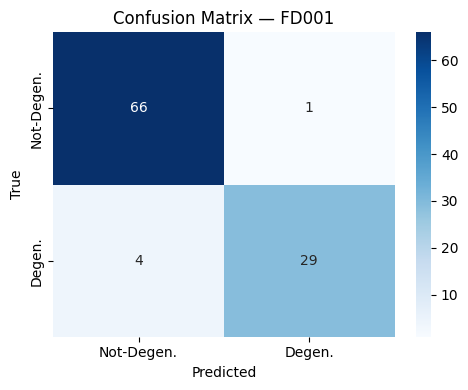

--------------------------------------------------

      PROCESSING DATASET: FD002
  Detected 6 operating regime(s) for FD002
[FD002] Epoch 15/150 | Val Loss: 1.3216 | Val Acc: 0.9378 | LR: 4.99e-04
[FD002] Epoch 30/150 | Val Loss: 1.7987 | Val Acc: 0.9292 | LR: 4.79e-04
[FD002] Epoch 45/150 | Val Loss: 1.8619 | Val Acc: 0.9297 | LR: 4.33e-04
[FD002] Epoch 50/150 | Val Loss: 1.8886 | Val Acc: 0.9261 | LR: 4.12e-04
[FD002] Early stopping triggered at Epoch 50 (Best Val Loss: 0.8396)

--- Evaluation Metrics on FD002 Test Set ---
Accuracy: 96.53% | RMSE: 12.78 | NASA Score: 755.36 | Mean Entropy: 0.2756
                 precision    recall  f1-score   support

Healthy       0.96      0.99      0.97       171
    Degraded       0.99      0.91      0.95        88

       accuracy                           0.97       259
      macro avg       0.97      0.95      0.96       259
   weighted avg       0.97      0.97      0.96       259



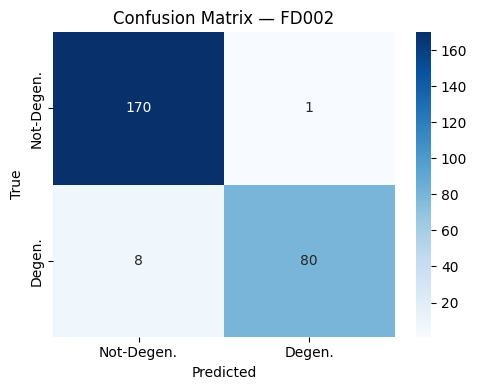

--------------------------------------------------

      PROCESSING DATASET: FD003
  Detected 1 operating regime(s) for FD003
[FD003] Epoch 15/150 | Val Loss: 0.7148 | Val Acc: 0.9407 | LR: 4.99e-04
[FD003] Epoch 30/150 | Val Loss: 1.2324 | Val Acc: 0.9647 | LR: 4.79e-04
[FD003] Epoch 45/150 | Val Loss: 1.4932 | Val Acc: 0.9601 | LR: 4.33e-04
[FD003] Epoch 55/150 | Val Loss: 1.7070 | Val Acc: 0.9609 | LR: 3.89e-04
[FD003] Early stopping triggered at Epoch 55 (Best Val Loss: 0.5994)

--- Evaluation Metrics on FD003 Test Set ---
Accuracy: 93.0% | RMSE: 11.88 | NASA Score: 271.75 | Mean Entropy: 0.2787
                 precision    recall  f1-score   support

Healthy       1.00      0.90      0.95        71
    Degraded       0.81      1.00      0.89        29

       accuracy                           0.93       100
      macro avg       0.90      0.95      0.92       100
   weighted avg       0.94      0.93      0.93       100



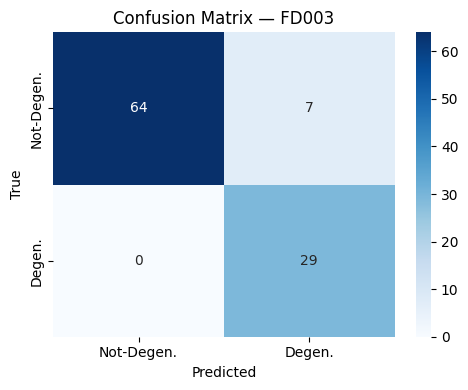

--------------------------------------------------

      PROCESSING DATASET: FD004
  Detected 6 operating regime(s) for FD004
[FD004] Epoch 15/150 | Val Loss: 1.4272 | Val Acc: 0.9362 | LR: 4.99e-04
[FD004] Epoch 30/150 | Val Loss: 1.9887 | Val Acc: 0.9513 | LR: 4.79e-04
[FD004] Epoch 45/150 | Val Loss: 2.1072 | Val Acc: 0.9519 | LR: 4.33e-04
[FD004] Epoch 52/150 | Val Loss: 2.1238 | Val Acc: 0.9527 | LR: 4.03e-04
[FD004] Early stopping triggered at Epoch 52 (Best Val Loss: 0.5779)

--- Evaluation Metrics on FD004 Test Set ---
Accuracy: 96.77% | RMSE: 13.65 | NASA Score: 943.14 | Mean Entropy: 0.3365
                 precision    recall  f1-score   support

Healthy       0.98      0.98      0.98       168
    Degraded       0.95      0.95      0.95        80

       accuracy                           0.97       248
      macro avg       0.96      0.96      0.96       248
   weighted avg       0.97      0.97      0.97       248



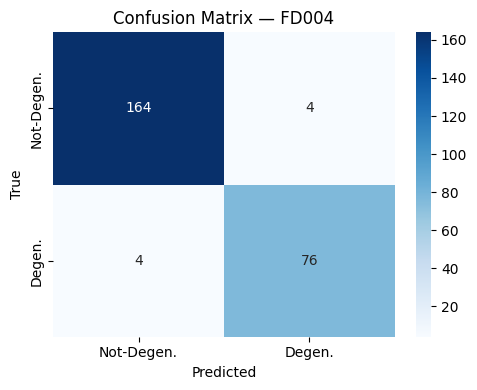

--------------------------------------------------

************************************************************
      STARTING BENCHMARK FOR SEED 43
************************************************************

      PROCESSING DATASET: FD001
  Detected 1 operating regime(s) for FD001
[FD001] Epoch 15/150 | Val Loss: 0.6746 | Val Acc: 0.9587 | LR: 4.99e-04
[FD001] Epoch 30/150 | Val Loss: 0.8788 | Val Acc: 0.9621 | LR: 4.79e-04
[FD001] Epoch 45/150 | Val Loss: 2.1044 | Val Acc: 0.9627 | LR: 4.33e-04
[FD001] Epoch 55/150 | Val Loss: 1.7498 | Val Acc: 0.9707 | LR: 3.89e-04
[FD001] Early stopping triggered at Epoch 55 (Best Val Loss: 0.6448)

--- Evaluation Metrics on FD001 Test Set ---
Accuracy: 96.0% | RMSE: 13.79 | NASA Score: 379.69 | Mean Entropy: 0.2894
                 precision    recall  f1-score   support

Healthy       0.97      0.97      0.97        67
    Degraded       0.94      0.94      0.94        33

       accuracy                           0.96       100
      macro a

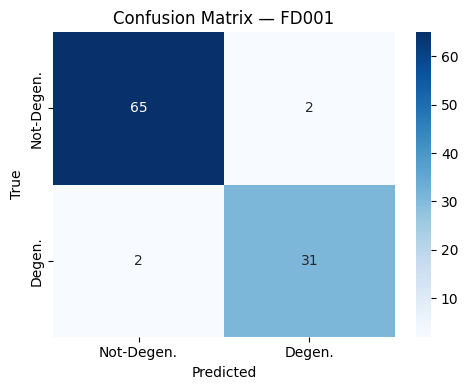

--------------------------------------------------

      PROCESSING DATASET: FD002
  Detected 6 operating regime(s) for FD002
[FD002] Epoch 15/150 | Val Loss: 1.8392 | Val Acc: 0.9259 | LR: 4.99e-04
[FD002] Epoch 30/150 | Val Loss: 1.8743 | Val Acc: 0.9307 | LR: 4.79e-04
[FD002] Epoch 45/150 | Val Loss: 1.9865 | Val Acc: 0.9332 | LR: 4.33e-04
[FD002] Epoch 51/150 | Val Loss: 1.7417 | Val Acc: 0.9320 | LR: 4.08e-04
[FD002] Early stopping triggered at Epoch 51 (Best Val Loss: 0.8519)

--- Evaluation Metrics on FD002 Test Set ---
Accuracy: 97.3% | RMSE: 13.69 | NASA Score: 937.17 | Mean Entropy: 0.2748
                 precision    recall  f1-score   support

Healthy       0.97      0.99      0.98       171
    Degraded       0.98      0.94      0.96        88

       accuracy                           0.97       259
      macro avg       0.97      0.97      0.97       259
   weighted avg       0.97      0.97      0.97       259



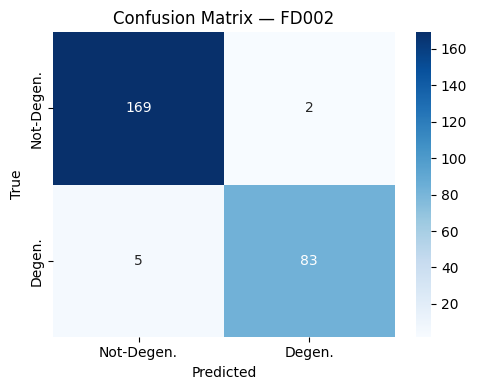

--------------------------------------------------

      PROCESSING DATASET: FD003
  Detected 1 operating regime(s) for FD003
[FD003] Epoch 15/150 | Val Loss: 0.9502 | Val Acc: 0.9617 | LR: 4.99e-04
[FD003] Epoch 30/150 | Val Loss: 1.5571 | Val Acc: 0.9676 | LR: 4.79e-04
[FD003] Epoch 45/150 | Val Loss: 1.4096 | Val Acc: 0.9559 | LR: 4.33e-04
[FD003] Epoch 55/150 | Val Loss: 1.7327 | Val Acc: 0.9623 | LR: 3.89e-04
[FD003] Early stopping triggered at Epoch 55 (Best Val Loss: 0.6127)

--- Evaluation Metrics on FD003 Test Set ---
Accuracy: 95.0% | RMSE: 11.4 | NASA Score: 224.72 | Mean Entropy: 0.2467
                 precision    recall  f1-score   support

Healthy       0.99      0.94      0.96        71
    Degraded       0.88      0.97      0.92        29

       accuracy                           0.95       100
      macro avg       0.93      0.95      0.94       100
   weighted avg       0.95      0.95      0.95       100



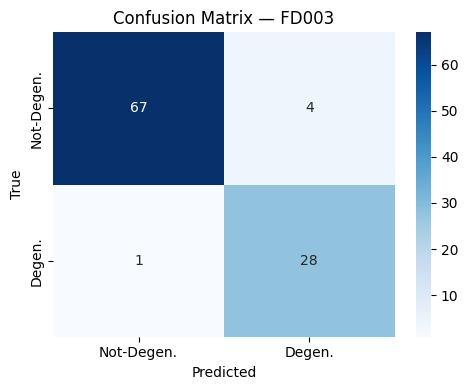

--------------------------------------------------

      PROCESSING DATASET: FD004
  Detected 6 operating regime(s) for FD004
[FD004] Epoch 15/150 | Val Loss: 1.9269 | Val Acc: 0.9532 | LR: 4.99e-04
[FD004] Epoch 30/150 | Val Loss: 2.0839 | Val Acc: 0.9483 | LR: 4.79e-04
[FD004] Epoch 45/150 | Val Loss: 2.1371 | Val Acc: 0.9514 | LR: 4.33e-04
[FD004] Epoch 51/150 | Val Loss: 2.1827 | Val Acc: 0.9502 | LR: 4.08e-04
[FD004] Early stopping triggered at Epoch 51 (Best Val Loss: 0.6093)

--- Evaluation Metrics on FD004 Test Set ---
Accuracy: 95.97% | RMSE: 14.12 | NASA Score: 1092.35 | Mean Entropy: 0.3331
                 precision    recall  f1-score   support

Healthy       0.96      0.98      0.97       168
    Degraded       0.96      0.91      0.94        80

       accuracy                           0.96       248
      macro avg       0.96      0.95      0.95       248
   weighted avg       0.96      0.96      0.96       248



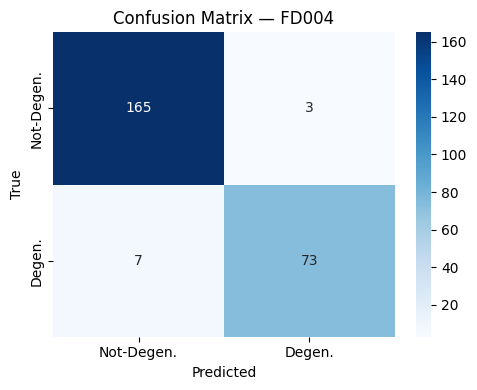

--------------------------------------------------

************************************************************
      STARTING BENCHMARK FOR SEED 44
************************************************************

      PROCESSING DATASET: FD001
  Detected 1 operating regime(s) for FD001
[FD001] Epoch 15/150 | Val Loss: 0.8140 | Val Acc: 0.9664 | LR: 4.99e-04
[FD001] Epoch 30/150 | Val Loss: 1.6085 | Val Acc: 0.9675 | LR: 4.79e-04
[FD001] Epoch 45/150 | Val Loss: 1.6703 | Val Acc: 0.9695 | LR: 4.33e-04
[FD001] Epoch 54/150 | Val Loss: 1.7410 | Val Acc: 0.9761 | LR: 3.94e-04
[FD001] Early stopping triggered at Epoch 54 (Best Val Loss: 0.6500)

--- Evaluation Metrics on FD001 Test Set ---
Accuracy: 96.0% | RMSE: 13.88 | NASA Score: 393.22 | Mean Entropy: 0.2479
                 precision    recall  f1-score   support

Healthy       0.96      0.99      0.97        67
    Degraded       0.97      0.91      0.94        33

       accuracy                           0.96       100
      macro a

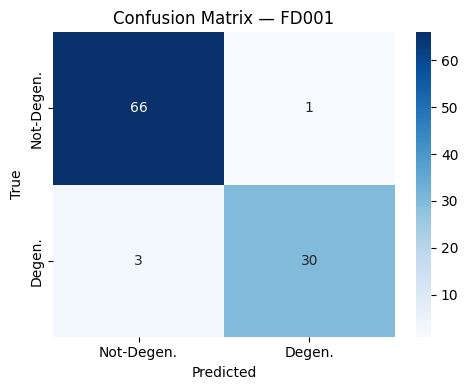

--------------------------------------------------

      PROCESSING DATASET: FD002
  Detected 6 operating regime(s) for FD002
[FD002] Epoch 15/150 | Val Loss: 1.5588 | Val Acc: 0.9280 | LR: 4.99e-04
[FD002] Epoch 30/150 | Val Loss: 1.8715 | Val Acc: 0.9226 | LR: 4.79e-04
[FD002] Epoch 45/150 | Val Loss: 1.9479 | Val Acc: 0.9269 | LR: 4.33e-04
[FD002] Epoch 53/150 | Val Loss: 1.7794 | Val Acc: 0.9252 | LR: 3.99e-04
[FD002] Early stopping triggered at Epoch 53 (Best Val Loss: 0.8616)

--- Evaluation Metrics on FD002 Test Set ---
Accuracy: 96.91% | RMSE: 14.37 | NASA Score: 1297.32 | Mean Entropy: 0.2116
                 precision    recall  f1-score   support

Healthy       0.98      0.97      0.98       171
    Degraded       0.94      0.97      0.96        88

       accuracy                           0.97       259
      macro avg       0.96      0.97      0.97       259
   weighted avg       0.97      0.97      0.97       259



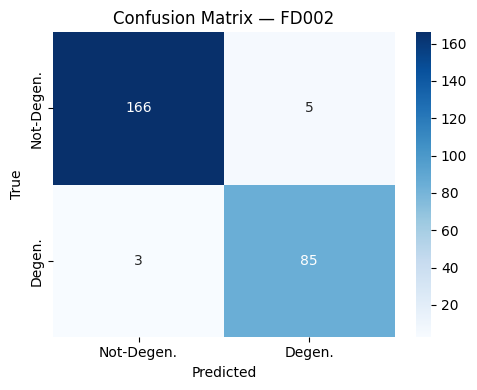

--------------------------------------------------

      PROCESSING DATASET: FD003
  Detected 1 operating regime(s) for FD003
[FD003] Epoch 15/150 | Val Loss: 1.0263 | Val Acc: 0.9609 | LR: 4.99e-04
[FD003] Epoch 30/150 | Val Loss: 1.4595 | Val Acc: 0.9660 | LR: 4.79e-04
[FD003] Epoch 45/150 | Val Loss: 1.4805 | Val Acc: 0.9660 | LR: 4.33e-04
[FD003] Epoch 55/150 | Val Loss: 1.6747 | Val Acc: 0.9615 | LR: 3.89e-04
[FD003] Early stopping triggered at Epoch 55 (Best Val Loss: 0.6097)

--- Evaluation Metrics on FD003 Test Set ---
Accuracy: 92.0% | RMSE: 13.36 | NASA Score: 380.1 | Mean Entropy: 0.257
                 precision    recall  f1-score   support

Healthy       1.00      0.89      0.94        71
    Degraded       0.78      1.00      0.88        29

       accuracy                           0.92       100
      macro avg       0.89      0.94      0.91       100
   weighted avg       0.94      0.92      0.92       100



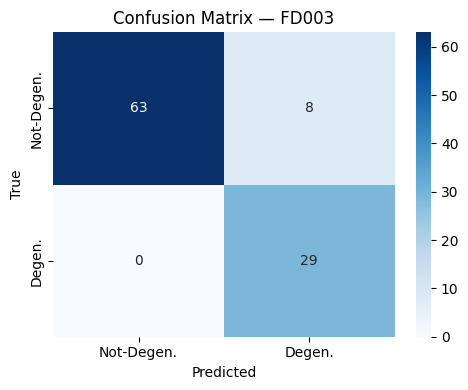

--------------------------------------------------

      PROCESSING DATASET: FD004
  Detected 6 operating regime(s) for FD004
[FD004] Epoch 15/150 | Val Loss: 1.7915 | Val Acc: 0.9503 | LR: 4.99e-04
[FD004] Epoch 30/150 | Val Loss: 2.0197 | Val Acc: 0.9468 | LR: 4.79e-04
[FD004] Epoch 45/150 | Val Loss: 2.0427 | Val Acc: 0.9492 | LR: 4.33e-04
[FD004] Epoch 51/150 | Val Loss: 1.8469 | Val Acc: 0.9488 | LR: 4.08e-04
[FD004] Early stopping triggered at Epoch 51 (Best Val Loss: 0.5956)

--- Evaluation Metrics on FD004 Test Set ---
Accuracy: 95.97% | RMSE: 13.8 | NASA Score: 912.61 | Mean Entropy: 0.3842
                 precision    recall  f1-score   support

Healthy       0.99      0.95      0.97       168
    Degraded       0.91      0.97      0.94        80

       accuracy                           0.96       248
      macro avg       0.95      0.96      0.95       248
   weighted avg       0.96      0.96      0.96       248



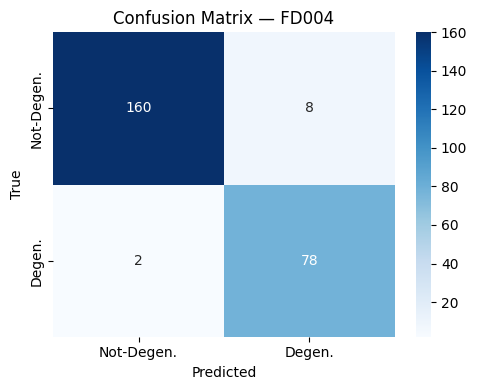

--------------------------------------------------

              FINAL MULTI-DATASET BENCHMARK RESULTS (MEAN ± STD over 3 SEEDS)
Dataset     Accuracy    Precision       Recall     F1-Score         RMSE      NASA Score NASA Score (Per Engine) Mean Entropy
  FD001 95.67 ± 0.58 95.72 ± 0.42 94.46 ± 1.17 95.03 ± 0.71  13.72 ± 0.2  374.93 ± 21.07             3.75 ± 0.21  0.25 ± 0.03
  FD002 96.91 ± 0.39 96.95 ± 0.55  96.19 ± 0.9 96.53 ± 0.46  13.61 ± 0.8 996.62 ± 275.83             3.85 ± 1.06  0.25 ± 0.04
  FD003 93.33 ± 1.53 90.83 ± 1.97 94.97 ± 0.55  92.36 ± 1.6 12.21 ± 1.02  292.19 ± 79.68             2.92 ± 0.79  0.26 ± 0.02
  FD004 96.24 ± 0.46 95.68 ± 0.84  95.8 ± 0.93  95.7 ± 0.53 13.86 ± 0.24   982.7 ± 96.18             3.96 ± 0.39  0.35 ± 0.03


,Dataset,Accuracy,Precision,Recall,F1-Score,RMSE,NASA Score,NASA Score (Per Engine),Mean Entropy
0,FD001,95.67 ± 0.58,95.72 ± 0.42,94.46 ± 1.17,95.03 ± 0.71,13.72 ± 0.2,374.93 ± 21.07,3.75 ± 0.21,0.25 ± 0.03
1,FD002,96.91 ± 0.39,96.95 ± 0.55,96.19 ± 0.9,96.53 ± 0.46,13.61 ± 0.8,996.62 ± 275.83,3.85 ± 1.06,0.25 ± 0.04
2,FD003,93.33 ± 1.53,90.83 ± 1.97,94.97 ± 0.55,92.36 ± 1.6,12.21 ± 1.02,292.19 ± 79.68,2.92 ± 0.79,0.26 ± 0.02
3,FD004,96.24 ± 0.46,95.68 ± 0.84,95.8 ± 0.93,95.7 ± 0.53,13.86 ± 0.24,982.7 ± 96.18,3.96 ± 0.39,0.35 ± 0.03


In [17]:
all_results       = []
models_dict       = {}
test_tensors_dict = {}
test_targets_dict = {}
test_preds_dict   = {}
features_dict     = {}
test_regimes_dict = {}
test_preds_reg_by_seed = {ds: {} for ds in ['FD001', 'FD002', 'FD003', 'FD004']}

seeds = [42, 43, 44]
seed_results = []

for seed in seeds:
    print(f"\n{'*'*60}\n      STARTING BENCHMARK FOR SEED {seed}\n{'*'*60}")
    for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
        try:
            res, model_ds, test_t, t_cls, p_cls, feats, r_test, preds_reg = \
                train_and_evaluate_dataset(ds, epochs=EPOCHS, sequence_length=SEQ_LENGTH, seed=seed)
            res['Seed'] = seed
            seed_results.append(res)

            # Save the models and tensors for the last seed
            models_dict[ds]       = model_ds
            test_tensors_dict[ds] = test_t
            test_targets_dict[ds] = t_cls
            test_preds_dict[ds]   = p_cls
            features_dict[ds]     = feats
            test_regimes_dict[ds] = r_test
            test_preds_reg_by_seed[ds][seed] = preds_reg
        except Exception as e:
            print(f"\n[ERROR] Training failed for {ds} on seed {seed}: {e}\n")

df = pd.DataFrame(seed_results)

if df.empty:
    print("\n[WARNING] No results were collected due to training failures.")
    summary_df = pd.DataFrame()
else:
    # Group by Dataset and compute Mean ± Std for numerical columns
    grouped = df.groupby('Dataset').agg(['mean', 'std']).round(2)
    summary_df = pd.DataFrame(index=grouped.index)

    for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'RMSE', 'NASA Score', 'NASA Score (Per Engine)', 'Mean Entropy']:
        if col in grouped.columns.levels[0]:
            summary_df[col] = grouped[col]['mean'].astype(str) + " ± " + grouped[col]['std'].astype(str)

    summary_df = summary_df.reset_index()

    print("\n" + "=" * 105)
    print("              FINAL MULTI-DATASET BENCHMARK RESULTS (MEAN ± STD over 3 SEEDS)")
    print("=" * 105)
    print(summary_df.to_string(index=False))
    print("=" * 105)

# Display the final summary dataframe directly
summary_df


Generating plot for FD001...
Generating plot for FD002...
Generating plot for FD003...
Generating plot for FD004...


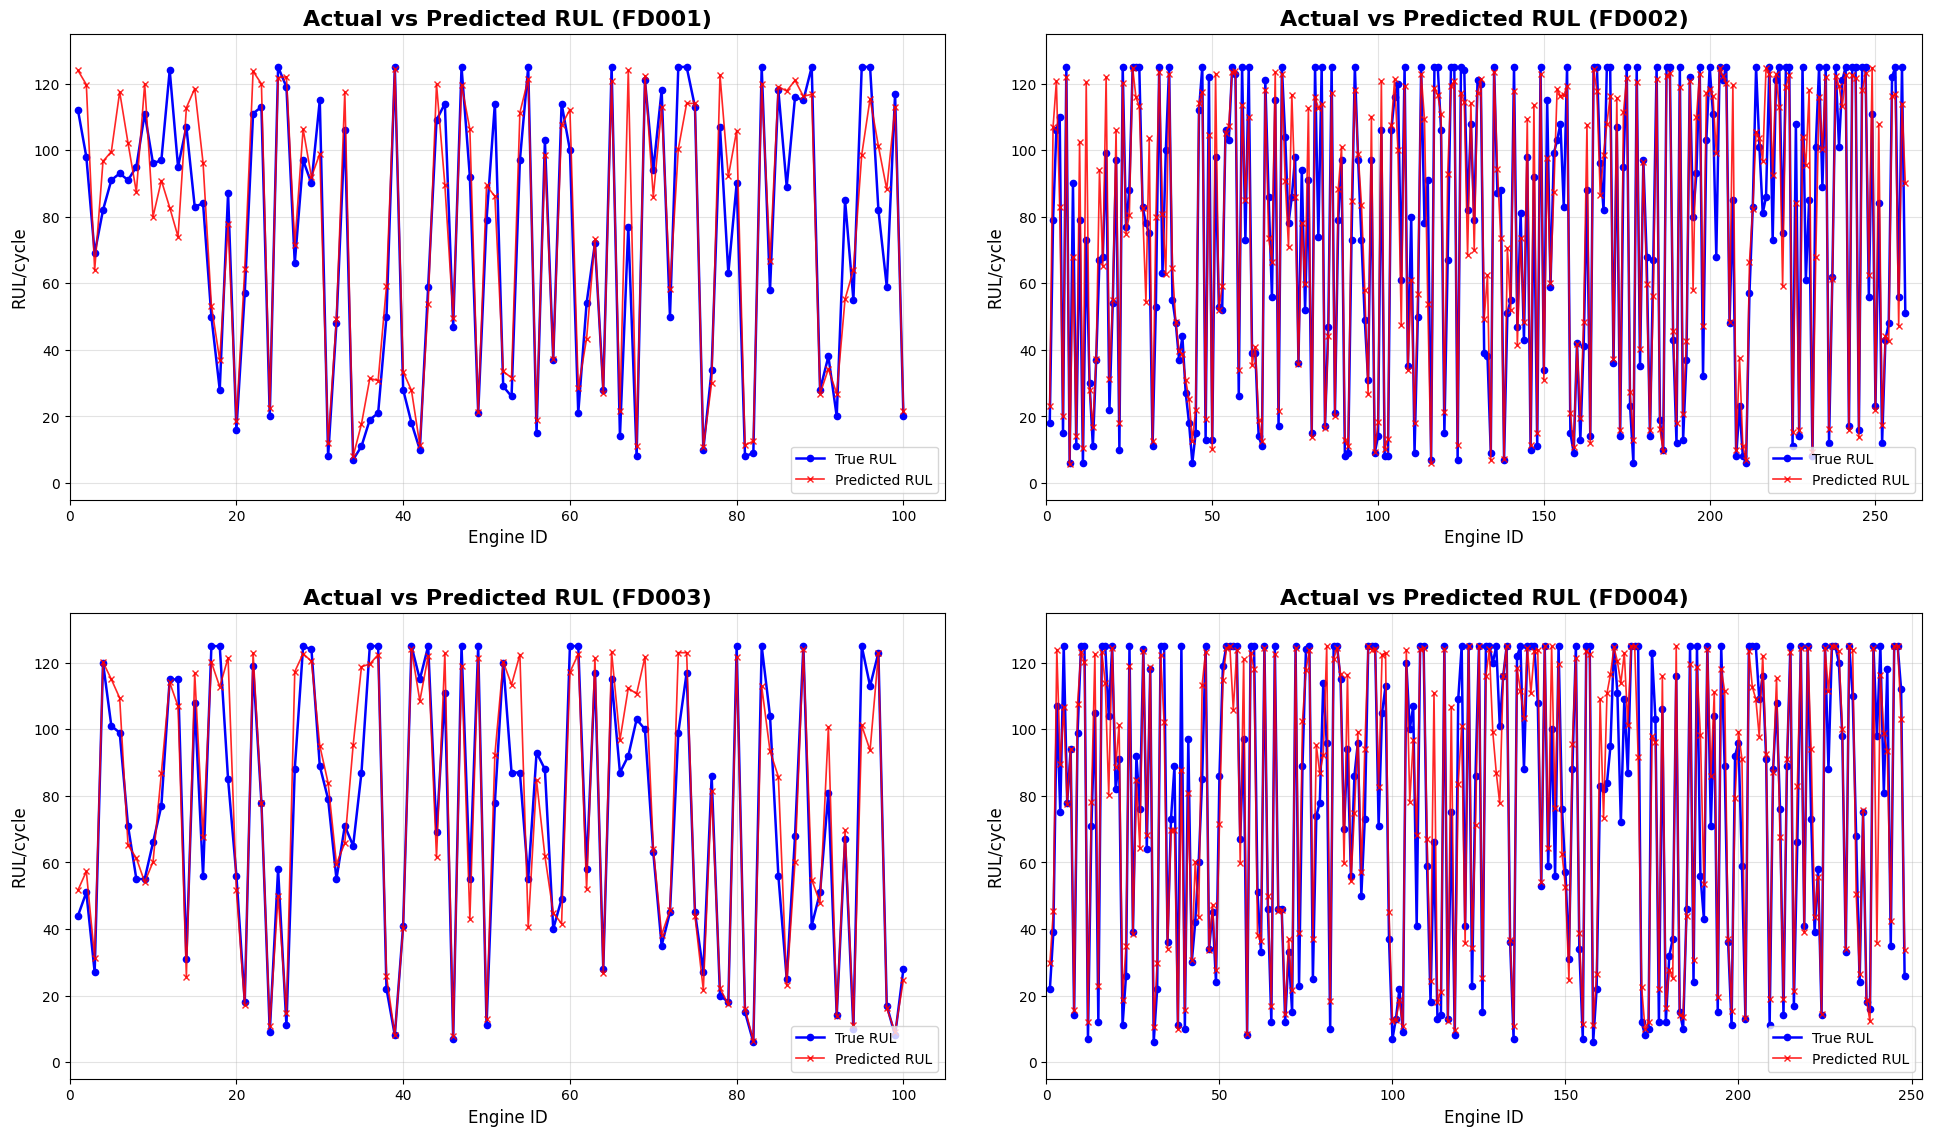

In [18]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

def plot_actual_vs_predicted_rul_all_datasets(seed_results_list):

    datasets = ['FD001', 'FD002', 'FD003', 'FD004']

    fig, axes = plt.subplots(
        2, 2,
        figsize=(20, 12)
    )

    axes = axes.flatten()

    for i, ds in enumerate(datasets):

        print(f"Generating plot for {ds}...")

        model = models_dict[ds]
        X_test_tensor = test_tensors_dict[ds]
        y_test_cls = test_targets_dict[ds]

        num_samples = X_test_tensor.size(0)
        seq_len = 40

        # --------------------------------------------------
        # --------------------------------------------------
        # Compute Averaged Predicted RUL across 3 Seeds
        # --------------------------------------------------
        all_seed_preds = np.array(list(test_preds_reg_by_seed[ds].values()))
        y_pred = np.mean(all_seed_preds, axis=0)
        y_pred = np.asarray(y_pred).reshape(-1)

        # --------------------------------------------------
        # Load TRUE RUL
        # --------------------------------------------------

        true_rul_df = pd.read_csv(
            get_file_path(f'RUL_{ds}.txt'),
            sep=r'\s+',
            header=None,
            names=['RUL']
        )

        y_true = true_rul_df['RUL'].values.astype(float)

        # Cap at 125
        y_true = np.clip(y_true, 0, 125)
        y_pred = np.clip(y_pred, 0, 125)

        # --------------------------------------------------
        # Match lengths
        # --------------------------------------------------

        n = min(
            len(y_true),
            len(y_pred)
        )

        y_true = y_true[:n]
        y_pred = y_pred[:n]

        engine_ids = np.arange(1, n + 1)

        # --------------------------------------------------
        # Plot
        # --------------------------------------------------

        ax = axes[i]

        # TRUE RUL
        ax.plot(
            engine_ids,
            y_true,
            color='blue',
            marker='o',
            markersize=4.5,
            linewidth=1.8,
            linestyle='-',
            label='True RUL'
        )

        # PREDICTED RUL
        ax.plot(
            engine_ids,
            y_pred,
            color='red',
            marker='x',
            markersize=5,
            linewidth=1.2,
            linestyle='-',
            alpha=0.85,
            label='Predicted RUL'
        )

        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------

        ax.set_title(
            f'Actual vs Predicted RUL ({ds})',
            fontsize=16,
            fontweight='bold'
        )

        ax.set_xlabel(
            'Engine ID',
            fontsize=12
        )

        ax.set_ylabel(
            'RUL/cycle',
            fontsize=12
        )

        ax.set_ylim(
            -5,
            135
        )

        ax.set_xlim(
            0,
            n + 5
        )

        ax.grid(
            True,
            linestyle='-',
            linewidth=0.8,
            alpha=0.35
        )

        ax.legend(
            loc='lower right',
            fontsize=10,
            frameon=True
        )

    # ------------------------------------------------------
    # Overall layout
    # ------------------------------------------------------

    plt.tight_layout(
        pad=3.0
    )

    plt.show()


# ==========================================================
# RUN FOR ALL 4 DATASETS
# ==========================================================

plot_actual_vs_predicted_rul_all_datasets(seed_results)

## 14. Conclusion

This notebook established a condition-aware framework for Remaining Useful Life (RUL) prediction using the NASA C-MAPSS turbofan engine dataset. The proposed Condition-Aware Dual-Stream Transformer integrates operating-regime information with complementary temporal representations from a multi-scale TCN and a conditioned BiGRU, followed by gated fusion and Transformer-based temporal modeling.

The multi-task formulation jointly addresses degradation classification and continuous RUL regression, while the asymmetric regression objective places greater emphasis on prediction errors according to their operational consequence. Across FD001–FD004, the framework provides consistent RUL prediction and degradation-classification performance over three random seeds.

MC Dropout further provides a stochastic predictive uncertainty signal through repeated inference, with classification entropy used as an additional indicator of predictive uncertainty. Overall, the implementation provides an integrated framework for condition-aware predictive maintenance and uncertainty-aware evaluation of turbofan engine degradation.